## This is the training file for the local model which stands as a proof of concept currently

In [1]:
import os
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.optim import Adam

import sys, os
sys.path.append(os.path.expanduser("~/Desktop/projects/audio-filler"))

from models.model2.model2 import AudioEncoder1


In [2]:
class MusicGenreDataset(Dataset):
    def __init__(self, data_dir, clip_duration=15, stride=1, sample_rate=16000):
        self.data_dir = Path(os.path.expanduser(str(data_dir)))
        self.clip_length = clip_duration * sample_rate
        self.stride = stride * sample_rate
        self.sample_rate = sample_rate
        
        # Get genre labels
        self.genres = sorted([d.name for d in self.data_dir.iterdir() if d.is_dir()])
        self.genre_to_idx = {genre: idx for idx, genre in enumerate(self.genres)}
        
        # Collect audio files and their genres
        self.audio_files = []
        for genre in self.genres:
            genre_dir = self.data_dir / genre
            for audio_file in genre_dir.glob("*.mp3"):
                self.audio_files.append((audio_file, genre))
        
        
        # Precompute clip segments
        self.clips = []
        for audio_file, genre in self.audio_files:
            info = torchaudio.info(audio_file)
            audio_sample_rate = info.sample_rate
            total_samples = info.num_frames
            start = 0
            while start < total_samples:
                end = start + (audio_sample_rate * clip_duration)  # clip_duration in seconds
                if end > total_samples:
                    if total_samples - start >= 10 * sample_rate:  # Check if at least 10s
                        end = total_samples
                        padding = self.clip_length - (end - start)
                        self.clips.append((audio_file, start, end, padding, genre))
                    break
                else:
                    self.clips.append((audio_file, start, end, 0, genre))
                start += self.stride

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        audio_file, start, end, padding, genre = self.clips[idx]
        waveform, sr = torchaudio.load(audio_file, frame_offset=start, num_frames=end-start)
        waveform = torchaudio.functional.resample(waveform, sr, self.sample_rate)[0]  # Convert to mono
        
        if padding > 0:
            waveform = torch.nn.functional.pad(waveform, (0, padding))
        
        # Add channel dimension
        waveform = waveform.unsqueeze(0)
        label = self.genre_to_idx[genre]
        
        return waveform, label

In [3]:
# Initialize dataset and dataloader
dataset = MusicGenreDataset("~/data/project/music")
dataloader = DataLoader(dataset, batch_size=1000, shuffle=True, num_workers=4)

/var/folders/1g/bksky7bd2wb927qzgc2fqjhc0000gn/T/ipykernel_18799/1271600113.py:23: UserWarning: torchaudio._backend.utils.info has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  info = torchaudio.info(audio_file)
/opt/anaconda3/envs/audio-filler/lib/python3.11/site-packages/torchaudio/_backend/soundfile_backend.py:71: UserWarning: The MPEG_LAYER_III subtype is unknown to TorchAudio. As a result, the bits_per_sample attribute will be set to 0. If you are seeing this warning, please report by opening an issue on github (after checking for existing/closed ones). You may otherwise ignore this warning.
  warnings.warn(
/opt/anaconda3/envs/audio-filler/lib/python3.11/site-packages/tor

In [4]:
# length of batches
len(dataloader)

565

In [5]:
dataset[2][0].shape  # Example shape of a single audio clip

/opt/anaconda3/envs/audio-filler/lib/python3.11/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
[src/libmpg123/layer3.c:INT123_do_layer3():1776] error: part2_3_length (1664) too large for available bit count (1504)


torch.Size([1, 240000])

In [6]:
import pandas as pd

# Extract genre names and their corresponding clip counts
genre_counts = {}
for clip in dataset.clips:
    # clip[4] is the genre name
    genre_name = clip[4]
    genre_counts[genre_name] = genre_counts.get(genre_name, 0) + 1

# Create DataFrame
df_genres = pd.DataFrame({
    'genre': list(genre_counts.keys()),
    'count': list(genre_counts.values())
})

# Add genre_id for reference
df_genres['genre_id'] = df_genres['genre'].map(dataset.genre_to_idx)

print(df_genres)

              genre  count  genre_id
0             blues  40609         0
1         classical  60841         1
2           country  24049         2
3              folk  39169         3
4            hiphop  33243         4
5              jazz  62584         5
6              lofi  17356         6
7             metal  42014         7
8               pop  28685         8
9               rnb  30615         9
10      rock-garage  29078        10
11        rock-goth  31732        11
12  rock-industrial  46358        12
13   rock-krautrock  52971        13
14        rock-punk  25568        14


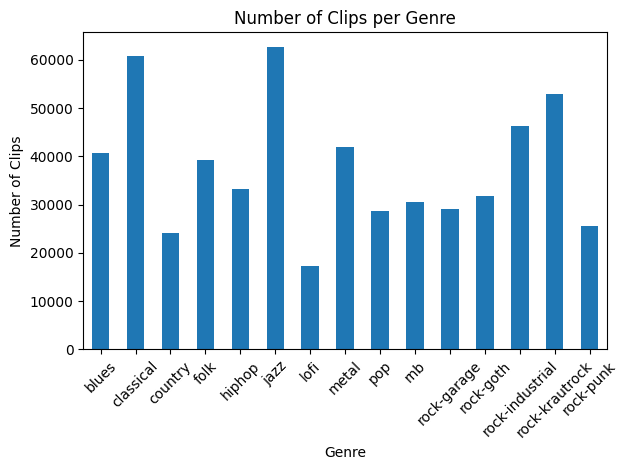

In [7]:
# Plot directly from DataFrame
df_genres.plot.bar(x='genre', y='count', legend=False)
plt.title('Number of Clips per Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Clips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import os
from pathlib import Path
import torch
import torchaudio
from torch.utils.data import DataLoader

# --- Initialize your dataset ---
dataset = MusicGenreDataset("~/data/project/music")
dataloader_1 = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=4)

# --- Output directory ---
save_dir = Path("../example").expanduser()
save_dir.mkdir(parents=True, exist_ok=True)

# --- Save 100 examples ---
num_samples = 100
for i, (waveform, label) in enumerate(dataloader_1):
    if i >= num_samples:
        break
    
    # Convert label to genre name
    genre = dataset.genres[label.item()]
    
    # Make subfolder for genre
    genre_dir = save_dir / genre
    genre_dir.mkdir(parents=True, exist_ok=True)
    
    # Save waveform as .wav
    file_path = genre_dir / f"sample_{i:03d}.wav"
    torchaudio.save(file_path, waveform.squeeze(0), sample_rate=dataset.sample_rate)
    
    # Optionally save label text too
    with open(file_path.with_suffix('.txt'), 'w') as f:
        f.write(genre)
    
    print(f"Saved: {file_path} ({genre})")

print(f"\n✅ Done! Saved {num_samples} samples in: {save_dir}")
